In [1]:
from pathlib import Path

import pandapower as pp
from pandapower.converter.cim.cim2pp.from_cim import from_cim

# Keep the EQ file and any future TP/SSH/SV companion profiles together.
model_dir = Path.cwd()
xml_files = sorted(model_dir.glob("*.xml"))
if not xml_files:
    raise FileNotFoundError("No CGMES XML files were found in the notebook folder.")

print("Profiles:")
for path in xml_files:
    print(f"  - {path.name}")

net = from_cim(
    [str(path) for path in xml_files],
    cgmes_version="2.4.15",
    ignore_errors=True,
    run_powerflow=False,
)

# Show what cim2pp was able to construct from the supplied profiles.
element_tables = [
    "bus", "line", "trafo", "sgen", "gen", "load", "shunt", "ext_grid", "switch"
]
summary = {table: len(net[table]) for table in element_tables}
print("\nPandapower element counts:")
print(summary)

# EQ describes equipment, while TP/SSH/SV profiles normally supply topology and state.
required_columns = {
    "bus": ["vn_kv"],
    "line": ["from_bus", "to_bus"],
    "trafo": ["hv_bus", "lv_bus"],
    "load": ["bus", "p_mw", "q_mvar"],
    "sgen": ["bus", "p_mw", "q_mvar"],
}
missing = {}
for table, columns in required_columns.items():
    if net[table].empty:
        continue
    invalid = net[table][columns].isna().any(axis=1)
    if invalid.any():
        missing[table] = int(invalid.sum())

if not net.ext_grid.empty:
    print("\nExisting slack buses:")
    print(net.ext_grid[["bus", "vm_pu"]])

if missing or net.ext_grid.empty:
    print("\nPower flow was not run.")
    print("The supplied EQ profile is not a complete simulation case:")
    if missing:
        print(f"  Missing topology/operating values: {missing}")
    if net.ext_grid.empty:
        print("  No ext_grid/slack source is defined.")
    print("Add the matching CGMES TP, SSH and (where available) SV profiles, then rerun this cell.")
else:
    pp.runpp(net, init="auto")
    print(f"\nPower flow converged: {net.converged}")
    display(net.res_bus)
    display(net.res_line)
    display(net.res_trafo)


Profiles:
  - 20210325T1530Z_1D_NL_EQ_001 3.xml


c:\Users\Kristoferis\miniconda3\envs\BRCC_practical_tasks\Lib\site-packages\pandapower\converter\cim\cim2pp\converter_classes\connectivitynodes\connectivityNodesCim16.py:209: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  pd.concat([eqssh_terminals, self.cimConverter.cim['eq_bd']['Terminal'][['rdfId', 'ConductingEquipment',
c:\Users\Kristoferis\miniconda3\envs\BRCC_practical_tasks\Lib\site-packages\pandapower\converter\cim\cim2pp\converter_classes\connectivitynodes\connectivityNodesCim16.py:246: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcas


Pandapower element counts:
{'bus': 3, 'line': 5, 'trafo': 3, 'sgen': 2, 'gen': 0, 'load': 3, 'shunt': 1, 'ext_grid': 0, 'switch': 0}

Power flow was not run.
The supplied EQ profile is not a complete simulation case:
  Missing topology/operating values: {'bus': 2, 'line': 5, 'load': 3, 'sgen': 2}
  No ext_grid/slack source is defined.
Add the matching CGMES TP, SSH and (where available) SV profiles, then rerun this cell.


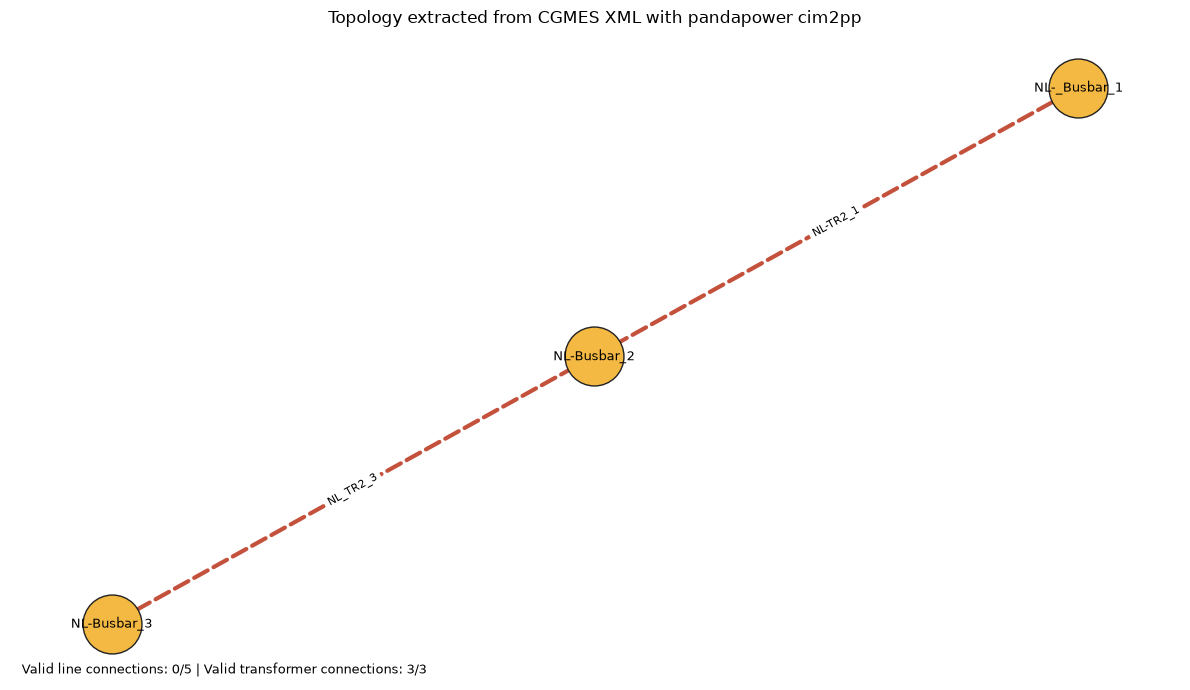

In [2]:
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd

# Plot the topology that cim2pp extracted. Invalid/incomplete references are omitted.
graph = nx.Graph()
for bus_index, bus in net.bus.iterrows():
    graph.add_node(bus_index, label=bus.get("name", f"Bus {bus_index}"))

valid_line_count = 0
for line_index, line in net.line.iterrows():
    endpoints = line[["from_bus", "to_bus"]]
    if endpoints.isna().any():
        continue
    graph.add_edge(
        int(line.from_bus),
        int(line.to_bus),
        label=line.get("name", f"Line {line_index}"),
        kind="line",
    )
    valid_line_count += 1

valid_trafo_count = 0
for trafo_index, trafo in net.trafo.iterrows():
    endpoints = trafo[["hv_bus", "lv_bus"]]
    if endpoints.isna().any():
        continue
    graph.add_edge(
        int(trafo.hv_bus),
        int(trafo.lv_bus),
        label=trafo.get("name", f"Transformer {trafo_index}"),
        kind="transformer",
    )
    valid_trafo_count += 1

if graph.number_of_nodes() == 0:
    raise RuntimeError("No buses were extracted, so there is nothing to plot.")

positions = nx.spring_layout(graph, seed=42)
figure, axis = plt.subplots(figsize=(12, 7))

nx.draw_networkx_nodes(
    graph,
    positions,
    node_color="#f4b942",
    edgecolors="#222222",
    node_size=1800,
    ax=axis,
)
line_edges = [edge for edge in graph.edges(data=True) if edge[2]["kind"] == "line"]
trafo_edges = [edge for edge in graph.edges(data=True) if edge[2]["kind"] == "transformer"]
nx.draw_networkx_edges(graph, positions, edgelist=line_edges, edge_color="#2f6f9f", width=2.5, ax=axis)
nx.draw_networkx_edges(graph, positions, edgelist=trafo_edges, edge_color="#c4513b", width=3, style="dashed", ax=axis)
nx.draw_networkx_labels(
    graph,
    positions,
    labels=nx.get_node_attributes(graph, "label"),
    font_size=9,
    ax=axis,
)

edge_labels = {(u, v): data["label"] for u, v, data in graph.edges(data=True)}
nx.draw_networkx_edge_labels(graph, positions, edge_labels=edge_labels, font_size=8, ax=axis)
axis.set_title("Topology extracted from CGMES XML with pandapower cim2pp")
axis.axis("off")
axis.text(
    0.01,
    0.01,
    f"Valid line connections: {valid_line_count}/{len(net.line)} | "
    f"Valid transformer connections: {valid_trafo_count}/{len(net.trafo)}",
    transform=axis.transAxes,
    fontsize=9,
)
plt.tight_layout()
plt.show()


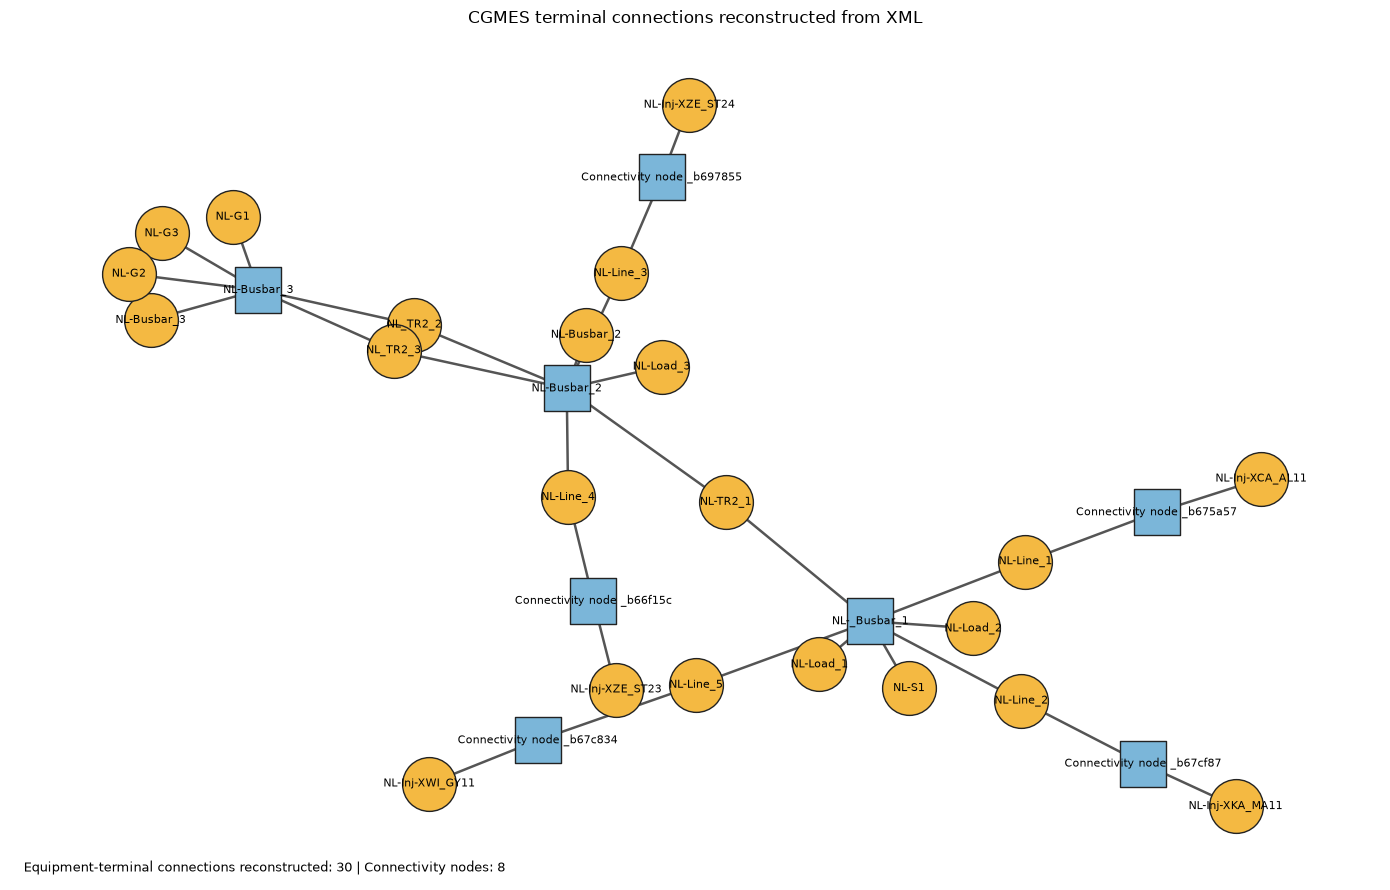

In [5]:
import xml.etree.ElementTree as ElementTree

# Reconstruct terminal connections in memory from the EQ XML.
# This does not modify the source XML or the pandapower net.
xml_root = ElementTree.parse(xml_files[0]).getroot()
rdf_resource = "{http://www.w3.org/1999/02/22-rdf-syntax-ns#}resource"
rdf_id = "{http://www.w3.org/1999/02/22-rdf-syntax-ns#}ID"
cim_namespace = "http://iec.ch/TC57/CIM100#"

object_names = {}
for element in xml_root.iter():
    object_id = element.get(rdf_id)
    if object_id:
        name_element = next(
            (child for child in element if child.tag == f"{{{cim_namespace}}}IdentifiedObject.name"),
            None,
        )
        object_names[object_id] = name_element.text if name_element is not None else object_id

terminal_edges = []
for terminal in xml_root.iter(f"{{{cim_namespace}}}Terminal"):
    equipment_reference = next(
        (child.get(rdf_resource) for child in terminal
         if child.tag == f"{{{cim_namespace}}}Terminal.ConductingEquipment"),
        None,
    )
    connectivity_reference = next(
        (child.get(rdf_resource) for child in terminal
         if child.tag == f"{{{cim_namespace}}}Terminal.ConnectivityNode"),
        None,
    )
    if equipment_reference and connectivity_reference:
        terminal_edges.append(
            (equipment_reference.lstrip("#"), connectivity_reference.lstrip("#"))
        )

if not terminal_edges:
    raise RuntimeError("No terminal connections were found in the EQ profile.")

def object_label(object_id, prefix):
    return object_names.get(object_id, f"{prefix} {object_id[:8]}")

xml_topology = nx.Graph()
for equipment_id, connectivity_id in terminal_edges:
    xml_topology.add_node(
        equipment_id,
        label=object_label(equipment_id, "Equipment"),
        kind="equipment",
    )
    xml_topology.add_node(
        connectivity_id,
        label=object_label(connectivity_id, "Connectivity node"),
        kind="connectivity node",
    )
    xml_topology.add_edge(equipment_id, connectivity_id)

xml_positions = nx.spring_layout(xml_topology, seed=42)
figure, axis = plt.subplots(figsize=(14, 9))
equipment_nodes = [node for node, data in xml_topology.nodes(data=True) if data["kind"] == "equipment"]
connectivity_nodes = [node for node, data in xml_topology.nodes(data=True) if data["kind"] == "connectivity node"]

nx.draw_networkx_nodes(
    xml_topology,
    xml_positions,
    nodelist=equipment_nodes,
    node_color="#f4b942",
    edgecolors="#222222",
    node_size=1500,
    ax=axis,
)
nx.draw_networkx_nodes(
    xml_topology,
    xml_positions,
    nodelist=connectivity_nodes,
    node_color="#7bb6d9",
    edgecolors="#222222",
    node_size=1100,
    node_shape="s",
    ax=axis,
)
nx.draw_networkx_edges(xml_topology, xml_positions, edge_color="#555555", width=1.8, ax=axis)
nx.draw_networkx_labels(
    xml_topology,
    xml_positions,
    labels=nx.get_node_attributes(xml_topology, "label"),
    font_size=8,
    ax=axis,
)
axis.set_title("CGMES terminal connections reconstructed from XML")
axis.text(
    0.01,
    0.01,
    f"Equipment-terminal connections reconstructed: {len(terminal_edges)} | "
    f"Connectivity nodes: {len(connectivity_nodes)}",
    transform=axis.transAxes,
    fontsize=9,
)
axis.axis("off")
plt.tight_layout()
plt.show()


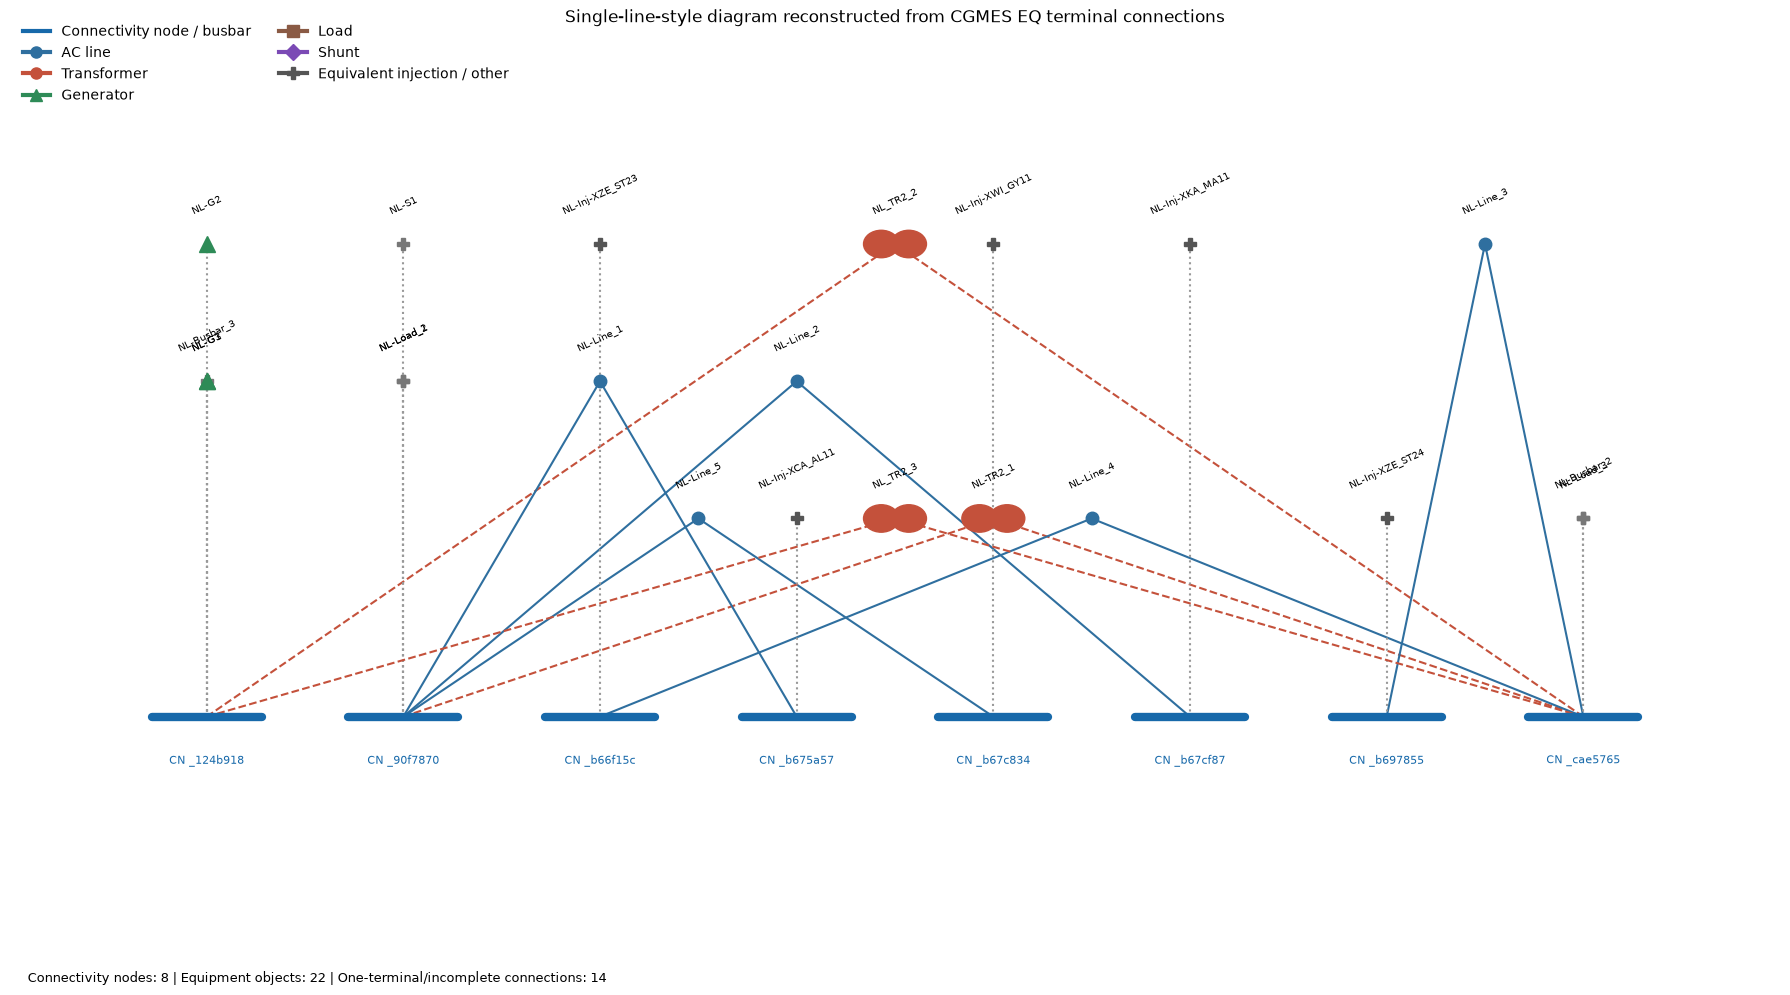

In [6]:
import matplotlib.patches as patches

# Build a conventional single-line-style view from the reconstructed EQ topology.
# Connectivity nodes become busbars; equipment is drawn between its terminal nodes.
rdf_id_attribute = "{http://www.w3.org/1999/02/22-rdf-syntax-ns#}ID"

equipment_types = {}
for element in xml_root.iter():
    element_id = element.get(rdf_id_attribute)
    if element_id:
        equipment_types[element_id] = element.tag.rsplit("}", 1)[-1]

connections_by_equipment = {}
for equipment_id, connectivity_id in terminal_edges:
    connections_by_equipment.setdefault(equipment_id, [])
    if connectivity_id not in connections_by_equipment[equipment_id]:
        connections_by_equipment[equipment_id].append(connectivity_id)

connectivity_ids = sorted({node_id for nodes in connections_by_equipment.values() for node_id in nodes})
connectivity_positions = {
    node_id: (index + 1, 0.0)
    for index, node_id in enumerate(connectivity_ids)
}

figure, axis = plt.subplots(figsize=(18, 10))
axis.set_xlim(0, len(connectivity_ids) + 1)
axis.set_ylim(-1.5, 4.5)
axis.axis("off")

# Draw the connectivity nodes as busbars.
for node_id, (x_position, y_position) in connectivity_positions.items():
    axis.plot(
        [x_position - 0.28, x_position + 0.28],
        [y_position, y_position],
        color="#1769aa",
        linewidth=6,
        solid_capstyle="round",
        zorder=3,
    )
    axis.text(
        x_position,
        y_position - 0.25,
        f"CN {node_id[:8]}",
        ha="center",
        va="top",
        fontsize=8,
        color="#1769aa",
    )

symbol_styles = {
    "ACLineSegment": ("line", "#2f6f9f", "-"),
    "PowerTransformer": ("transformer", "#c4513b", "--"),
    "SynchronousMachine": ("generator", "#2e8b57", "-"),
    "EnergyConsumer": ("load", "#8a5a44", "-"),
    "ShuntCompensator": ("shunt", "#7b4ab5", "-"),
    "EquivalentInjection": ("equivalent injection", "#555555", "-"),
}

incomplete_connections = 0
for equipment_index, (equipment_id, node_ids) in enumerate(connections_by_equipment.items()):
    equipment_type = equipment_types.get(equipment_id, "Equipment")
    equipment_name = object_names.get(equipment_id, equipment_id[:8])
    style_name, color, line_style = symbol_styles.get(
        equipment_type,
        (equipment_type, "#777777", "-"),
    )
    node_coordinates = [connectivity_positions[node_id] for node_id in node_ids]
    if len(node_coordinates) >= 2:
        first_x, first_y = node_coordinates[0]
        second_x, second_y = node_coordinates[1]
        equipment_x = (first_x + second_x) / 2
        equipment_y = 1.3 + (equipment_index % 3) * 0.9
        for node_x, node_y in node_coordinates[:2]:
            axis.plot(
                [node_x, equipment_x],
                [node_y, equipment_y],
                color=color,
                linestyle=line_style,
                linewidth=1.5,
                zorder=1,
            )
    elif len(node_coordinates) == 1:
        incomplete_connections += 1
        equipment_x, equipment_y = node_coordinates[0][0], 1.3 + (equipment_index % 3) * 0.9
        axis.plot(
            [equipment_x, equipment_x],
            [0.0, equipment_y],
            color="#999999",
            linestyle=":",
            linewidth=1.5,
            zorder=1,
        )
    else:
        continue

    if equipment_type == "PowerTransformer":
        symbol = patches.Circle((equipment_x - 0.07, equipment_y), 0.09, color=color, zorder=4)
        second_symbol = patches.Circle((equipment_x + 0.07, equipment_y), 0.09, color=color, zorder=4)
        axis.add_patch(symbol)
        axis.add_patch(second_symbol)
    elif equipment_type == "ACLineSegment":
        axis.plot(equipment_x, equipment_y, marker="o", markersize=9, color=color, zorder=4)
    elif equipment_type == "SynchronousMachine":
        axis.plot(equipment_x, equipment_y, marker="^", markersize=11, color=color, zorder=4)
    elif equipment_type == "EnergyConsumer":
        axis.plot(equipment_x, equipment_y, marker="s", markersize=9, color=color, zorder=4)
    elif equipment_type == "ShuntCompensator":
        axis.plot(equipment_x, equipment_y, marker="D", markersize=8, color=color, zorder=4)
    else:
        axis.plot(equipment_x, equipment_y, marker="P", markersize=9, color=color, zorder=4)

    axis.text(
        equipment_x,
        equipment_y + 0.18,
        equipment_name,
        ha="center",
        va="bottom",
        fontsize=7,
        rotation=25,
    )

legend_items = [
    ("#1769aa", "_", "Connectivity node / busbar"),
    ("#2f6f9f", "o", "AC line"),
    ("#c4513b", "o", "Transformer"),
    ("#2e8b57", "^", "Generator"),
    ("#8a5a44", "s", "Load"),
    ("#7b4ab5", "D", "Shunt"),
    ("#555555", "P", "Equivalent injection / other"),
]
for color, marker, label in legend_items:
    axis.plot([], [], color=color, marker=marker, linewidth=3, markersize=8, label=label)
axis.legend(loc="upper left", bbox_to_anchor=(0, 1.02), ncol=2, frameon=False)
axis.set_title("Single-line-style diagram reconstructed from CGMES EQ terminal connections")
axis.text(
    0.01,
    -0.04,
    f"Connectivity nodes: {len(connectivity_ids)} | Equipment objects: {len(connections_by_equipment)} | "
    f"One-terminal/incomplete connections: {incomplete_connections}",
    transform=axis.transAxes,
    fontsize=9,
)
plt.tight_layout()
plt.show()


### Plot elements

This figure is a **CGMES connectivity-topology graph** reconstructed from the XML. It is a bipartite graph: equipment is connected to connectivity nodes through terminals.

#### Connectivity nodes and "exit nodes"

CGMES does not define a separate element called an **exit node**. The blue squares are `ConnectivityNode` objects. They are shared electrical connection points inside a `ConnectivityNodeContainer`, such as a substation or voltage level. A node can therefore be viewed as an entry or exit point for several pieces of equipment, depending on the direction of the power-flow study. The XML describes topology, not a permanent direction of flow.

A connectivity node normally uses these identifiers and relationships:

- **`rdf:ID` / `IdentifiedObject.mRID`:** the unique identifier used to reference the node.
- **`IdentifiedObject.name`:** an optional human-readable name. In this plot, shortened UUIDs are shown when no useful name is available.
- **`ConnectivityNode.ConnectivityNodeContainer`:** the substation, voltage level, or other container in which the node belongs.
- **`Terminal.ConnectivityNode`:** the relationship that connects a terminal to the node.
- **`Terminal.ConductingEquipment`:** the relationship that identifies the equipment connected through that terminal.

Connectivity nodes do **not** normally carry parameters such as voltage magnitude, active power, reactive power, impedance, or current limits. Those values belong to the connected equipment or to other CGMES profiles:

- **Lines:** resistance, reactance, length, shunt susceptance, and operational current limits.
- **Transformers:** rated winding voltages, rated apparent power, impedance, winding connection, and tap-changer data.
- **Generators:** nominal and maximum active power, apparent-power rating, voltage rating, and reactive-power limits.
- **Loads:** active and reactive demand, normally supplied through SSH/SV operating-state data.
- **Terminals:** phase information, sequence number, and equipment/node references.

#### Other plot elements

- **Yellow circles: conducting equipment.** These are physical or electrical network objects that carry, inject, consume, transform, or control electrical power. Depending on the equipment present in the EQ profile, they can include `ACLineSegment` objects, `PowerTransformer` objects, generators or synchronous machines, loads, shunts, and equivalent injections. The label is the value of `IdentifiedObject.name`, such as `NL-Line_5` or `NL_TR2_2`.

- **Gray edges: CGMES terminal relationships.** Each gray edge represents one terminal association between conducting equipment and a connectivity node. The XML expresses this through `Terminal.ConductingEquipment` and `Terminal.ConnectivityNode`. A two-terminal line or transformer normally has two such connections.

- **Node positions: visual layout only.** The spring layout is calculated by NetworkX to make relationships visible. Distance and geometric position do not represent geographic distance, voltage level, impedance, or electrical distance.

- **What this figure does not show.** It does not show power direction, generation or load magnitude, voltage angle, current, line loading, protection limits, or a solved power-flow state. It shows structural connectivity reconstructed from the EQ profile, including connections that pandapower could not automatically map into complete bus endpoints.

For future reference it seems like the model doesn't neceseraly need to be solvable.  The subtasks are  (NUMBER one) to asses  the total production capacity of the generators in the model, (NUMBER 2) determine e the nominal voltages of the windings of the transformer NL_TR2_2 (ID: 
_2184f365-8cd5-4b5d-8a28-9d68603bb6a4), (NUMBER 3) determine What is the permanently allowed limit for line segment NL-Line_5 (ID: _e8acf6b6-99cb-45ad-b8dc-16c7866a4ddc ) and temporarily allowed? What is the difference 
between those limits?, (NUMBER 4) find Which generator is set as slack in the model? Why does the model need a slack node? and (NUMBER 5) Find mistakes in the model (semantic, power system related, and logical errors are all 
present).